In [1]:
import sys
import importlib

packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "torch": "torch",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib"
}

for import_name, install_name in packages.items():
    try:
        module = importlib.import_module(import_name)
        print(f"{import_name} installed | Version: {module.__version__}")
    except ImportError:
        print(f"{import_name} not installed. Installing...")
        !{sys.executable} -m pip install {install_name}
        print(f"{import_name} installed successfully\n")

print("\nCheck complete.")

pandas installed | Version: 2.3.3
numpy installed | Version: 2.2.6
torch installed | Version: 2.10.0+cu128
sklearn installed | Version: 1.7.2
matplotlib installed | Version: 3.10.8

Check complete.


In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import time

In [3]:
# 1. Load Data
df = pd.read_csv('two_hand_dataset.csv')

# Preprocessing: Identify feature columns vs label
# Assuming the last column is the label
X_raw = df.iloc[:, :-1].values 
y_raw = df.iloc[:, -1].values

# Label Encoding (e.g., 'A' -> 0, 'B' -> 1)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_raw)
num_classes = len(label_encoder.classes_)

# Normalization (Relative to wrist), This makes model robust to hand position on screen
def normalize_landmarks(data):
    # If 126 features (2 hands * 21 pts * 3 coords)
    # We subtract the wrist (first point of each hand) from all others
    for i in range(0, data.shape[1], 63): # Process each hand
        wrist_x, wrist_y, wrist_z = data[:, i], data[:, i+1], data[:, i+2]
        for j in range(21):
            data[:, i + j*3] -= wrist_x
            data[:, i + j*3 + 1] -= wrist_y
            data[:, i + j*3 + 2] -= wrist_z
    return data

X_norm = normalize_landmarks(X_raw)


In [4]:
# 2. Sequence Creation (The "Sequence Modelling" part)
def create_sequences(X, y, seq_len=10):
    sequences, labels = [], []
    for i in range(len(X) - seq_len):
        sequences.append(X[i:i+seq_len])
        labels.append(y[i+seq_len-1])
    return np.array(sequences), np.array(labels)

X_seq, y_seq = create_sequences(X_norm, y_encoded, seq_len=10)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42)

In [5]:
class BSLSequenceModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super(BSLSequenceModel, self).__init__()
        
        # Bidirectional GRU: Captures temporal flow in both directions
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True, 
                          bidirectional=True, num_layers=2, dropout=0.2)
        
        # Output layer
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
        
    def forward(self, x):
        # x shape: [batch, seq_len, features]
        out, _ = self.gru(x)
        # Take only the last time step output
        out = self.fc(out[:, -1, :])
        return out

# Initialize
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BSLSequenceModel(input_dim=X_raw.shape[1], hidden_dim=64, num_classes=num_classes).to(device)
print(f"Model initialized on {device}")

Model initialized on cuda


In [6]:
# Training Loop (Run for 15 Epochs)

# Convert to Tensors
train_data = torch.utils.data.TensorDataset(torch.Tensor(X_train), torch.LongTensor(y_train))
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

history = {'loss': [], 'acc': []}

print("Starting Initial Training (15 Epochs)...")
for epoch in range(15):
    model.train()
    total_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    history['loss'].append(total_loss/len(train_loader))
    if epoch % 5 == 0:
        print(f"Epoch {epoch} | Loss: {total_loss/len(train_loader):.4f}")

# Final Accuracy Check
model.eval()
with torch.no_grad():
    test_outputs = model(torch.Tensor(X_test).to(device))
    _, predicted = torch.max(test_outputs, 1)
    acc = (predicted == torch.LongTensor(y_test).to(device)).sum().item() / len(y_test)
    print(f"\nFinal Baseline Accuracy: {acc*100:.2f}%")

Starting Initial Training (15 Epochs)...
Epoch 0 | Loss: 2.3880
Epoch 5 | Loss: 0.2802
Epoch 10 | Loss: 0.2008

Final Baseline Accuracy: 98.45%


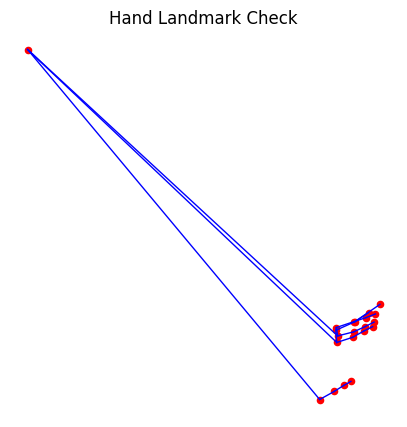

In [7]:
def plot_skeleton_final(features, title="Verification"):
    # features is 126 or 191 length. We take the first 63 (Hand 1)
    hand1 = features[:63].reshape(21, 3)
    
    # Connections for the hand
    connections = [
        (0,1), (1,2), (2,3), (3,4), (0,5), (5,6), (6,7), (7,8),
        (5,9), (9,10), (10,11), (11,12), (9,13), (13,14), (14,15), 
        (14,16), (13,17), (0,17), (17,18), (18,19), (19,20)
    ]
    
    plt.figure(figsize=(5,5))
    # Plotting x and y (negate y to flip it)
    plt.scatter(hand1[:, 0], -hand1[:, 1], c='r', s=20)
    
    for connection in connections:
        x_pts = [hand1[connection[0], 0], hand1[connection[1], 0]]
        y_pts = [-hand1[connection[0], 1], -hand1[connection[1], 1]]
        plt.plot(x_pts, y_pts, 'b-', linewidth=1)
        
    plt.title(title)
    plt.axis('off')
    plt.show()

# Run this on a row from your X_norm
plot_skeleton_final(X_norm[0], title="Hand Landmark Check")

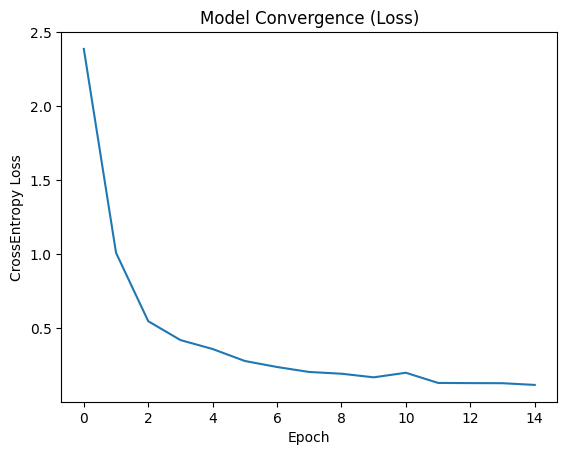

--- PERFORMANCE METRICS ---
Inference Time: 0.52 ms per sign
Potential FPS: 1936 frames per second


In [8]:
# Efficiency & Results Summary

# Plot Loss Curve
plt.plot(history['loss'])
plt.title('Model Convergence (Loss)')
plt.xlabel('Epoch')
plt.ylabel('CrossEntropy Loss')
plt.show()

# Inference Speed Test (Key for your RQ)
model.eval()
dummy_input = torch.randn(1, 10, X_raw.shape[1]).to(device)
start_time = time.time()
for _ in range(100):
    _ = model(dummy_input)
avg_inference = (time.time() - start_time) / 100 * 1000

print(f"--- PERFORMANCE METRICS ---")
print(f"Inference Time: {avg_inference:.2f} ms per sign")
print(f"Potential FPS: {1000/avg_inference:.0f} frames per second")

In [9]:
import json
import os

# Create a folder for results
results_dir = "experiment_results_v1"
os.makedirs(results_dir, exist_ok=True)

# Save the trained model
torch.save(model.state_dict(), f"{results_dir}/bsl_model.pth")

# Save the training logs
logs = {
    "epochs": list(range(15)),
    "train_loss": history['loss'],
    "final_accuracy": acc,
    "inference_speed_ms": avg_inference
}

with open(f"{results_dir}/training_logs.json", "w") as f:
    json.dump(logs, f)

print(f"Model and logs saved to {results_dir}")

Model and logs saved to experiment_results_v1


In [10]:
def predict_random_sample():
    model.eval()
    idx = np.random.randint(0, len(X_test))
    sample = torch.Tensor(X_test[idx]).unsqueeze(0).to(device) # Shape: [1, 10, 126]
    
    with torch.no_grad():
        output = model(sample)
        _, predicted_idx = torch.max(output, 1)
        
    predicted_letter = label_encoder.inverse_transform([predicted_idx.item()])[0]
    actual_letter = label_encoder.inverse_transform([y_test[idx]])[0]
    
    print(f"Predicted: {predicted_letter} | Actual: {actual_letter}")
    return predicted_letter == actual_letter

# Run this 5 times to show your supervisor
for _ in range(5):
    predict_random_sample()

Predicted: R - r | Actual: R - r
Predicted: I - i | Actual: I - i
Predicted: K - k | Actual: K - k
Predicted: D - d | Actual: D - d
Predicted: T - t | Actual: T - t


In [ ]:
import cv2
import mediapipe as mp


# 1. Initialize MediaPipe
mp_hands = mp.solutions.hands
hands_detector = mp_hands.Hands(static_image_mode=True, max_num_hands=2, min_detection_confidence=0.5)

def test_on_raw_folder(folder_path):
    images = [f for f in os.listdir(folder_path) if f.endswith('.png')]
    model.eval()
    
    # Setup plotting
    cols = 4
    rows = (len(images) // cols) + 1
    fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
    axes = axes.flatten()

    for i, img_name in enumerate(images):
        img_path = os.path.join(folder_path, img_name)
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # A. MediaPipe Landmark Extraction
        results = hands_detector.process(img_rgb)
        
        # Prepare feature vector (126 features for 2-hand model)
        # Initialize with zeros in case second hand isn't found
        land_data = np.zeros(126) 
        
        if results.multi_hand_landmarks:
            for h_idx, hand_lms in enumerate(results.multi_hand_landmarks):
                if h_idx >= 2: break # Only take first 2 hands
                for l_idx, lm in enumerate(hand_lms.landmark):
                    # Fill x, y, z for current hand
                    base_idx = h_idx * 63 + l_idx * 3
                    land_data[base_idx] = lm.x
                    land_data[base_idx + 1] = lm.y
                    land_data[base_idx + 2] = lm.z
        
        # B. Prediction
        # Create a sequence of 10 identical frames (static image simulation)
        seq_input = np.tile(land_data, (10, 1)) 
        input_tensor = torch.Tensor(seq_input).unsqueeze(0).to(device)
        
        with torch.no_grad():
            output = model(input_tensor)
            _, pred = torch.max(output, 1)
            prediction = label_encoder.inverse_transform([pred.item()])[0]
        
        # C. Visualization
        axes[i].imshow(img_rgb)
        axes[i].set_title(f"File: {img_name}\nPred: {prediction}", fontsize=14, color='green', fontweight='bold')
        axes[i].axis('off')
        
    # Clean up empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.savefig(f"{results_dir}/raw_testing_results.png")
    plt.show()

# Run the test
test_on_raw_folder('raw-data')

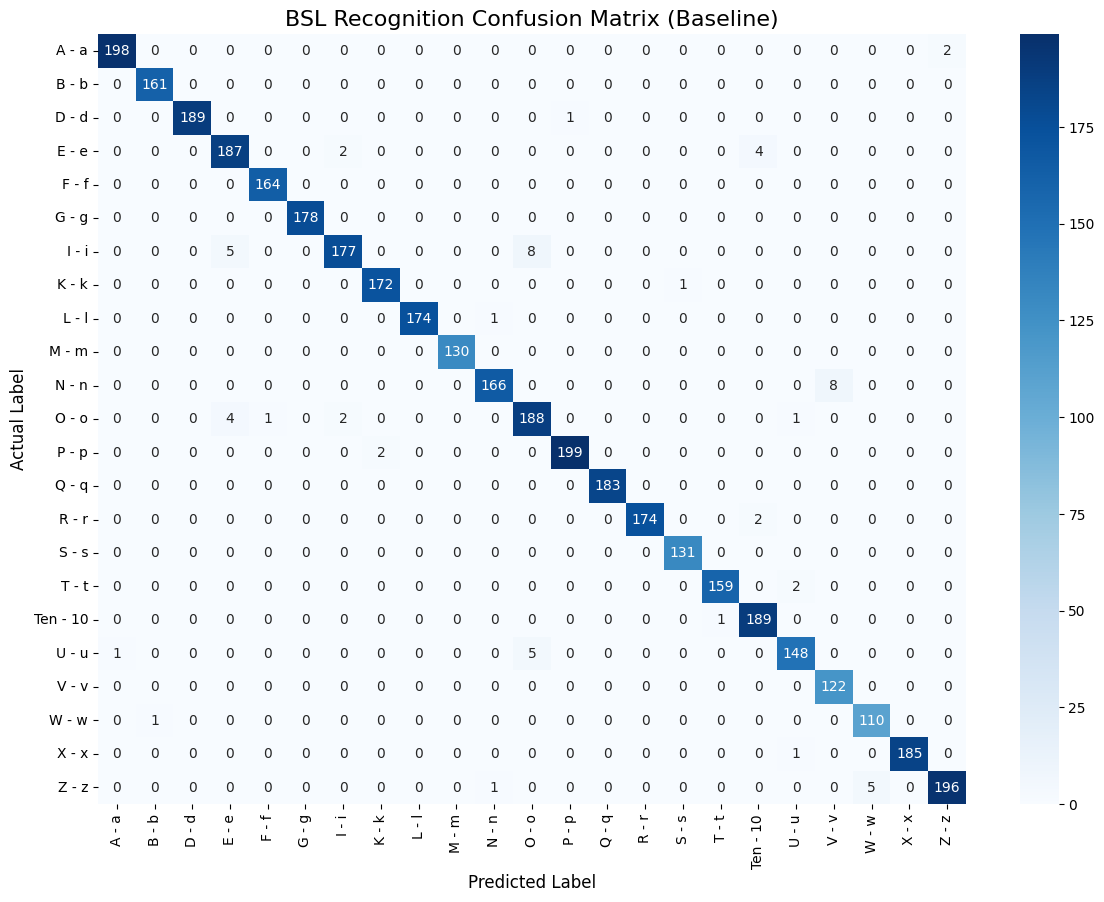

Confusion Matrix and Classification Report saved.


In [16]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def generate_final_stats():
    model.eval()
    all_preds = []
    all_true = []
    
    with torch.no_grad():
        # Using the test set we split earlier
        test_loader = DataLoader(torch.utils.data.TensorDataset(torch.Tensor(X_test), torch.LongTensor(y_test)), 
                                  batch_size=32, shuffle=False)
        
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device)
            outputs = model(batch_x)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_true.extend(batch_y.numpy())

    # Create Confusion Matrix
    cm = confusion_matrix(all_true, all_preds)
    plt.figure(figsize=(14, 10))
    
    # Use the label_encoder to show actual letters/numbers on the axis
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=label_encoder.classes_, 
                yticklabels=label_encoder.classes_)
    
    plt.title('BSL Recognition Confusion Matrix (Baseline)', fontsize=16)
    plt.ylabel('Actual Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    
    # Save the plot
    plt.savefig(f"{results_dir}/final_confusion_matrix.png", dpi=300)
    plt.show()

    # Save detailed text report
    report = classification_report(all_true, all_preds, target_names=label_encoder.classes_)
    with open(f"{results_dir}/classification_report.txt", "w") as f:
        f.write(report)
    print("Confusion Matrix and Classification Report saved.")

generate_final_stats()

In [ ]:

#import sys
# !{sys.executable} -m pip install mediapipe
#!{sys.executable} -m pip install seaborn

In [15]:
'''
import seaborn as sns
print("Seaborn version:", sns.__version__)
'''

Seaborn version: 0.13.2


In [12]:
'''
import mediapipe as mp
print(mp.__version__)
'''

0.10.32


In [11]:
'''
import mediapipe
print(mediapipe.__file__)
'''

/home/rurouni/miniconda3/envs/mediapipe_env/lib/python3.10/site-packages/mediapipe/__init__.py


In [1]:
'''
import mediapipe as mp

print("Version:", mp.__version__)
print("Dir contains solutions?:", "solutions" in dir(mp))

print(mp.solutions)
'''

Version: 0.10.32
Dir contains solutions?: False


AttributeError: module 'mediapipe' has no attribute 'solutions'

In [4]:
'''
import mediapipe
import os

print(mediapipe.__file__)

path = os.path.dirname(mediapipe.__file__)
print("Package folder:", path)
print("Files inside:")
print(os.listdir(path))
'''

/home/rurouni/miniconda3/envs/mediapipe_env/lib/python3.10/site-packages/mediapipe/__init__.py
Package folder: /home/rurouni/miniconda3/envs/mediapipe_env/lib/python3.10/site-packages/mediapipe
Files inside:
['__pycache__', 'tasks', 'modules', '__init__.py']


In [1]:
'''
import mediapipe as mp

print("Version:", mp.__version__)
print("solutions in dir:", "solutions" in dir(mp))

print(mp.solutions)
'''

Version: 0.10.11
solutions in dir: True
<module 'mediapipe.python.solutions' from '/home/rurouni/miniconda3/envs/mediapipe_env/lib/python3.10/site-packages/mediapipe/python/solutions/__init__.py'>
